In [3]:
import pandas as pd
import numpy as np
#import data as csv
df = pd.read_csv(
    "fashion_trends_combined.csv"
)

print(df.describe(include='all'))

df["date"] = pd.to_datetime(
    df["date"]
)
df.category.value_counts(normalize=True)

              date   trend_name  google_score    category
count        11004        11004  11004.000000       11004
unique         262           42           NaN           9
top     2020-12-27  Airy Styles           NaN  Womenswear
freq            42          262           NaN        3406
mean           NaN          NaN     23.297528         NaN
std            NaN          NaN     24.964189         NaN
min            NaN          NaN      0.000000         NaN
25%            NaN          NaN      0.000000         NaN
50%            NaN          NaN     18.000000         NaN
75%            NaN          NaN     41.000000         NaN
max            NaN          NaN    100.000000         NaN


category
Womenswear             0.309524
Streetwear             0.190476
Accessories            0.166667
Footwear               0.095238
Material Trend         0.095238
Colour Trend           0.071429
Unisex                 0.023810
Denim                  0.023810
Sustainable Fashion    0.023810
Name: proportion, dtype: float64

In [4]:
#Feature Engineering 
#sort data
df = df.sort_values(
    ["trend_name", "date"])

#date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

#lag features 
for lag in [1,2,3]:

    df[f"lag_{lag}"] = (
        df.groupby("trend_name")
        ["google_score"]
        .shift(lag)
    )

#log growth rate 
df["growth_rate"] = (
    np.log1p(df["google_score"])
    - np.log1p(df["lag_1"])
)

#3 month rolling avg
df["rolling_3m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(3).mean()
      )
)
#6 month rolling avg
df["rolling_6m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(6).mean()
      )
)

#volatility
df["volatility_3m"] = (
    df.groupby("trend_name")
      ["google_score"]
      .transform(
          lambda x:
          x.rolling(3).std()
      )
)
#acceleration
df["previous_growth"] = (
    df.groupby("trend_name")
      ["growth_rate"]
      .shift(1)
)

df["acceleration"] = (
    df["growth_rate"]
    - df["previous_growth"]
)

In [5]:
#creating a prediction target 
#future score
df["future_score"] = (
    df.groupby("trend_name")
      ["google_score"]
      .shift(-3)
)
#future growth
df["future_log_growth"] = (
    np.log1p(df["future_score"])
    - np.log1p(df["google_score"])
)
#top 25% 
threshold = df["future_log_growth"].quantile(0.75)
#This defines "emerging trends" as the top quartile of future growth.
df["trend_status"] = (
    df["future_log_growth"] > threshold
).astype(int)

print(df.describe(include='all'))


                       date          trend_name  google_score    category  \
count                 11004               11004  11004.000000       11004   
unique                  NaN                  42           NaN           9   
top                     NaN  Adidas Samba Style           NaN  Womenswear   
freq                    NaN                 262           NaN        3406   
mean    2023-06-28 12:00:00                 NaN     23.297528         NaN   
min     2020-12-27 00:00:00                 NaN      0.000000         NaN   
25%     2022-03-27 00:00:00                 NaN      0.000000         NaN   
50%     2023-06-28 12:00:00                 NaN     18.000000         NaN   
75%     2024-09-29 00:00:00                 NaN     41.000000         NaN   
max     2025-12-28 00:00:00                 NaN    100.000000         NaN   
std                     NaN                 NaN     24.964189         NaN   

                year         month       quarter         lag_1         lag_

In [6]:
#create columns to drop NaNs
model_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_3m",
    "rolling_6m",
    "volatility_3m",
    "acceleration",
    "trend_status"
]
#df with NaNs
print(df.shape)
#dropping nans and printing df_clean
df_clean = df.dropna(subset=model_cols)
print(df_clean.shape)
#checking percentage change between old and new df
rows_kept = len(df_clean) / len(df) * 100
print(f"{rows_kept:.1f}% of rows retained")

#drop missing valaues on specified columns 
df_model = df.dropna(subset=model_cols)
print(df_model.shape)
print(df_model.columns.tolist())


(11004, 19)
(10794, 19)
98.1% of rows retained
(10794, 19)
['date', 'trend_name', 'google_score', 'category', 'year', 'month', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'growth_rate', 'rolling_3m', 'rolling_6m', 'volatility_3m', 'previous_growth', 'acceleration', 'future_score', 'future_log_growth', 'trend_status']


In [7]:
#define target (y) and features (x)
y = df_model["trend_status"]

features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "growth_rate",
    "rolling_3m",
    "rolling_6m",
    "volatility_3m",
    "acceleration",
    "month",
    "quarter"
]

X = df_model[features]

#turn category into dummy features for modelling
X = pd.get_dummies(
    df_model[
        features + ["category"]
    ],
    drop_first=True
)

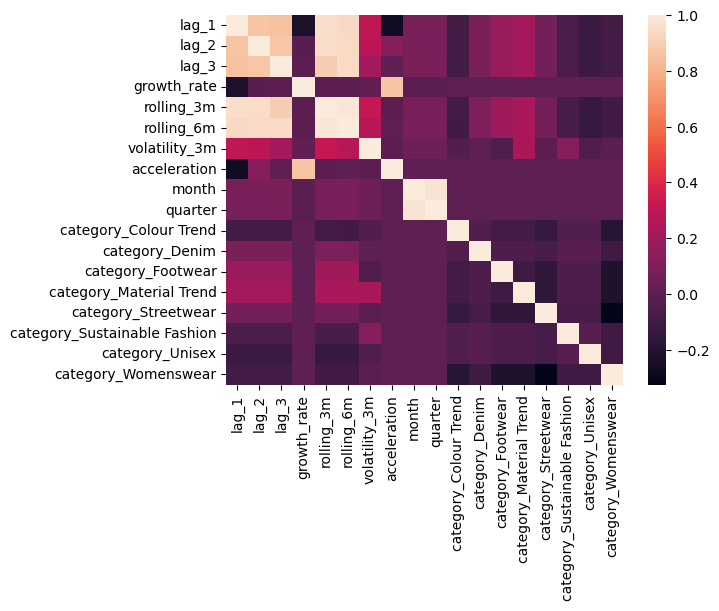

In [8]:
#Train test split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
import matplotlib.pyplot as plt
import seaborn as sns
#heatmap of X features
sns.heatmap(X.corr())
plt.show()
plt.close()

In [9]:
#Baseline Model LR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#crate model lr
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
#train the model
lr_model.fit(X_train, y_train)

#make predictions
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]


Accuracy: 0.7535896248263084
Precision: 0.5166666666666667
Recall: 0.05805243445692884
F1: 0.10437710437710437
ROC AUC: 0.7062754249495822
Confusion Matrix: [[1596   29]
 [ 503   31]]
            predicted no  predicted yes
actual no           1596             29
actual yes           503             31


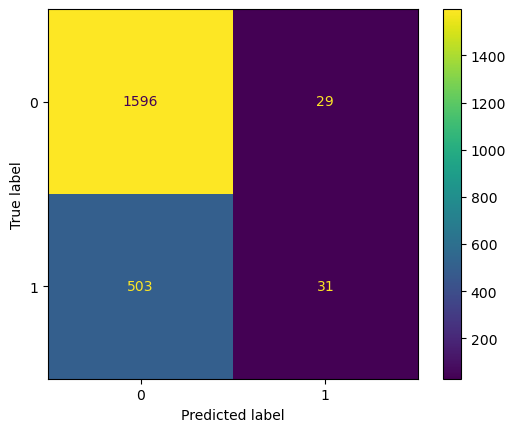

In [10]:
#Evaluation Metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve)

from sklearn.metrics import ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print('Confusion Matrix:', confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

test_conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, y_pred), 
    index=['actual no', 'actual yes'], 
    columns=['predicted no', 'predicted yes'])
print(test_conf_matrix)


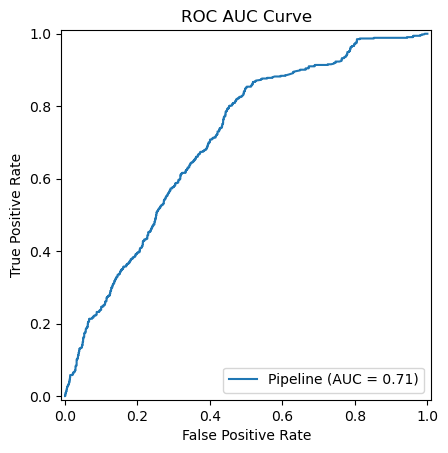

In [11]:
from sklearn.metrics import RocCurveDisplay
#Plot the ROC AUC Curve
# This automatically calculates probabilities and adds the AUC score to the legend
rcd = RocCurveDisplay.from_estimator(lr_model, X_test, y_test)

# 4. Customize and display the plot using matplotlib
plt.title("ROC AUC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


Accuracy: 0.7823066234367763
ROC AUC: 0.8192255834053586
Confusion Matrix: [[1484  141]
 [ 329  205]]
Precision: 0.5924855491329479
Recall: 0.3838951310861423
F1: 0.4659090909090909
            predicted no  predicted yes
actual no           1484            141
actual yes           329            205


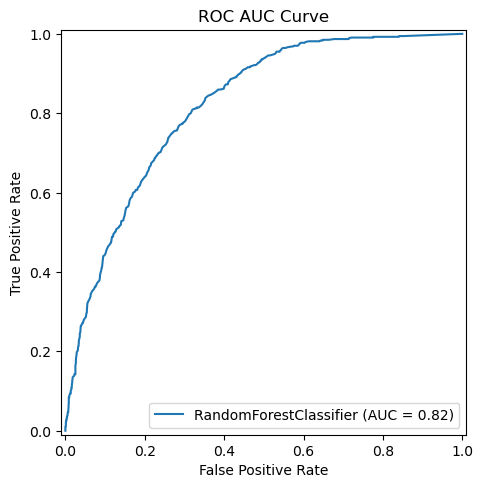

In [26]:
#Random forest 
from sklearn.ensemble import RandomForestClassifier
#instantiate model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
#training
rf.fit(X_train, y_train)
#predictions 
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))
print('Confusion Matrix:', confusion_matrix(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
#matrix as a DF 
test_conf_matrix_rf = pd.DataFrame(
    confusion_matrix(y_test, rf_pred), 
    index=['actual no', 'actual yes'], 
    columns=['predicted no', 'predicted yes'])
print(test_conf_matrix_rf)

#Plot the ROC AUC Curve
# This automatically calculates probabilities and adds the AUC score to the legend
rcd2 = RocCurveDisplay.from_estimator(rf, X_test, y_test)

# 4. Customize and display the plot using matplotlib
plt.tight_layout()

plt.title("ROC AUC Curve")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.savefig("roc_curve.png", dpi=300)
plt.show()

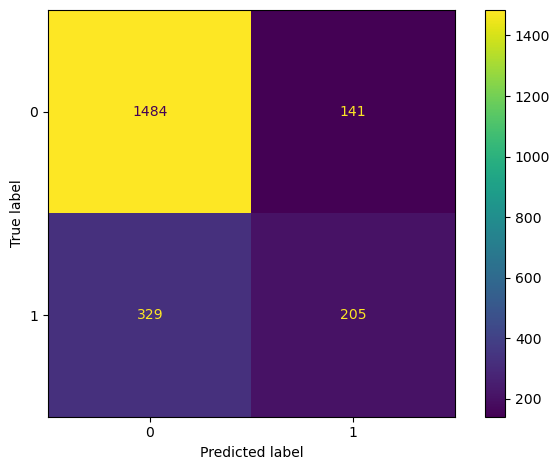

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

         Feature  Importance
5     rolling_6m    0.134300
3    growth_rate    0.124165
4     rolling_3m    0.116158
7   acceleration    0.103624
6  volatility_3m    0.101226
2          lag_3    0.098692
1          lag_2    0.082729
0          lag_1    0.081991
8          month    0.066713
9        quarter    0.025576


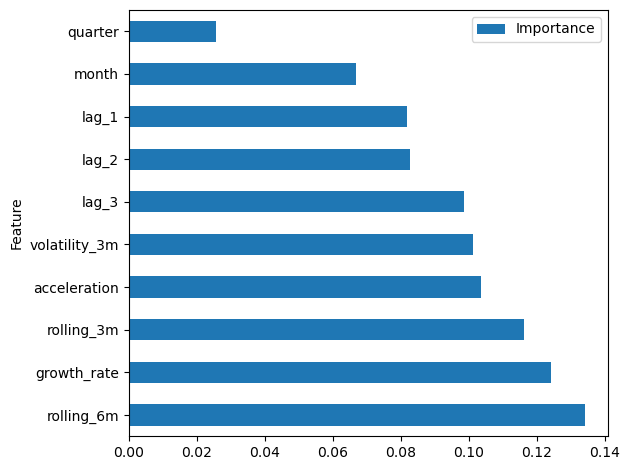

In [25]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": rf.feature_importances_})
importance = (importance.sort_values("Importance", ascending=False))
print(importance.head(10))

#plot importance
importance.head(10).plot(
    kind="barh",
    x="Feature",
    y="Importance"
)

plt.tight_layout()
plt.savefig(
    "feature_importance.png",
    dpi=300)

plt.show()

#growth rate and the rolling six month search average were the strongest 
#predictors of trend emergence 


In [14]:
#Cross Validation
#estimate how well your model will perform on 
#unseen data than a single train/test split by training on 
#multiple splits of data 
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GroupKFold
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)
print("Model Metrics for Standard Cross Validation:")
print("ROC AUC 5Fold:", scores)
print("Average ROC-AUC Performance:", scores.mean())
print("Standard Deviation:", scores.std())

      
#cross validation while keeping all the observations from trend_name together
#to ensure model has not already seen the trend in training as this can inflate performance
gkf = GroupKFold(n_splits=5)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=gkf,
    groups=df_model["trend_name"],
    scoring="roc_auc"
)
print("Model Metrics for Group Cross Validation:")
print("ROC AUC GroupKFold:", scores)
print("Average ROC-AUC Performance:", scores.mean())
print("Standard Deviation:", scores.std())

#A 5-fold Group Cross-Validation strategy was employed using trend names 
#as grouping variables to prevent data leakage between 
#observations of the same trend. 

#The Random Forest model achieved a mean ROC-AUC of 0.78 (SD = 0.02), 
#indicating consistent predictive performance across unseen fashion trends.

#The Random Forest model with GroupKFold cross validation performed the best
#(ROC-AUC=0.78), compared to the Logistic regression model (ROC-AUC=:0.68) 

Model Metrics for Standard Cross Validation:
ROC AUC 5Fold: [0.78718583 0.69731835 0.73805532 0.8373195  0.75682817]
Average ROC-AUC Performance: 0.7633414338793068
Standard Deviation: 0.047079013652991185
Model Metrics for Group Cross Validation:
ROC AUC GroupKFold: [0.75594155 0.74832673 0.81036874 0.75206779 0.81881632]
Average ROC-AUC Performance: 0.7771042274446691
Standard Deviation: 0.030819645722975037
